# PD for Regression: California Housing Example

This is demo of PD on both H2O and non-H2O models. 

California Housing dataset, price prediction - regression:

* `MedInc` median income in block
* `HouseAge` median house age in block
* `AveRooms` average number of rooms
* `AveBedrms` average number of bedrooms
* `Population` block population
* `AveOccup` average house occupancy
* `Latitude` house block latitude
* `Longitude`house block longitude

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from timeit import default_timer as timer

from mpl_toolkits.mplot3d import Axes3D

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble.partial_dependence import plot_partial_dependence
from sklearn.ensemble.partial_dependence import partial_dependence
from sklearn.datasets.california_housing import fetch_california_housing

from mli.explanation.pd import PD


cal_housing = fetch_california_housing()

# split 80/20 train-test
X_train, X_test, y_train, y_test = train_test_split(cal_housing.data,
                                                        cal_housing.target,
                                                        test_size=0.2,
                                                        random_state=1)

In [2]:
print(cal_housing['target'])
feature_list = cal_housing['feature_names'] + ['target']
print(feature_list)

[4.526 3.585 3.521 ... 0.923 0.847 0.894]
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'target']


### 1. Basic Data Munging

In [3]:
# Since, the loaded data is in the `sklearn.utils.Bunch` format we have to manually convert it to pandas dataframe
data_df = pd.DataFrame(data=np.c_[cal_housing['data'], cal_housing['target']],
                         columns=feature_list)

data_df_train = pd.DataFrame(data=np.c_[X_train, y_train],
                         columns=feature_list)

data_df_test = pd.DataFrame(data=np.c_[X_test, y_test],
                         columns=feature_list)
print(data_df_train.head(5))

print(f"Shape of the training data {data_df_train.shape}")
print(f"Shape of the test data {data_df_test.shape}")

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  3.1908      52.0  5.000000   1.014184       879.0  3.117021     37.71   
1  3.6094      42.0  4.900990   0.957096       971.0  3.204620     37.95   
2  2.6250      16.0  8.333333   1.666667        20.0  3.333333     37.90   
3  1.5143      34.0  3.805981   1.149526      3538.0  2.580598     34.02   
4  7.3356      38.0  5.894904   1.057325       750.0  2.388535     33.89   

   Longitude  target  
0    -122.43   2.556  
1    -122.35   1.146  
2    -121.24   1.375  
3    -118.35   1.188  
4    -118.39   4.227  
Shape of the training data (16512, 9)
Shape of the test data (4128, 9)


In [4]:
# Persist the data to used for DAI
data_df_train.to_csv("california_housing_train.csv", index=False)

### 2. Build a DAI model

In [5]:
# 1. Upload the data and build DAI model(adjusting the dial) 
# 2. Download the scoring pipeline from DAI
# 3. Use the .whl and the requirements.txt to install the scoring pipeline
# This notebook was last run using build: 1.5.0rc19

In [4]:
# If faced with a license error, generate a new one. 
import pandas as pd
import datatable as dt
import numpy as np
from numpy import nan
from scipy.special._ufuncs import expit
from scoring_h2oai_experiment_gowericu import Scorer

scorer = Scorer()

# Define a scoring function ...
def predict(X):
    # convert numpy or pandas to datatable
    return scorer.score_batch(X).iloc[:,0]


def predict_dt(X):
    X = dt.Frame(X)
    return scorer.score_batch(X).iloc[:,0]

('2019-01-03 04:36:08,990', 'License manager initialized')
('2019-01-03 04:36:08,991', '-----------------------------------------------------------------')
('2019-01-03 04:36:08,992', 'Checking whether we have a valid license...')
('2019-01-03 04:36:08,992', 'No Cloud provider found')
('2019-01-03 04:36:08,993', 'Read License from file as it was invalidated from environment')
('2019-01-03 04:36:08,994', 'License file exists (/home/ubuntu/.driverlessai/license.sig)')
('2019-01-03 04:36:09,003', '')
('2019-01-03 04:36:09,003', 'license_version:1')
('2019-01-03 04:36:09,004', 'serial_number:29')
('2019-01-03 04:36:09,005', 'licensee_organization:H2O.ai')
('2019-01-03 04:36:09,006', 'licensee_email:tomk@h2o.ai')
('2019-01-03 04:36:09,007', 'licensee_user_id:29')
('2019-01-03 04:36:09,008', 'is_h2o_internal_use:true')
('2019-01-03 04:36:09,008', 'created_by_email:tomk@h2o.ai')
('2019-01-03 04:36:09,009', 'creation_date:2018/11/26')
('2019-01-03 04:36:09,010', 'product:DriverlessAI')
('2019-

In [22]:
# Select all column except the last 'target' column
x_train_df = data_df.iloc[:, :-1]
# Since DAI accepts the frame where 'target' column is included.
feature_list_scoring = feature_list[:-1]

In [23]:
x_train_df.head(1)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.02381,322.0,2.555556,37.88,-122.23


#### 2.1 Using DataFrame for scoring(just for testing)

In [ ]:
# Quick check

start = timer()
predicted_scores = predict(x_train_df)
end = timer()

#print(predicted_scores)
print(f"Run time in secs: {end - start}")

# Run time in secs: 57.5

#### 2.2 Using DataTable for scoring (just for testing)

In [ ]:
import datatable as dt
# Directly reading the .csv
# datatable_train = dt.fread("./california_housing.csv")

# converting from pandas
X_dt = dt.Frame(x_train_df)
X_dt.head(1)

start = timer()
p_s = predict(X_dt)
end = timer()
print(end - start)

# Run time: 51.6s

#### 2.3 Generate Explanation

In [ ]:
pdp = PD("Boston Housing PD")
feature_names = ['MedInc']
start = timer()
pdp.explain(features=feature_names, X=x_train_df, predict_method=predict_dt)
end = timer()
print(end - start)

# Run time: 532.4s

In [14]:
result1 = pdp.explanations()

### 3. Build Non-DAI model (SK-learn)

In [15]:
print("Training GBRT...")
y = data_df['target']
clf = GradientBoostingRegressor(n_estimators=100, max_depth=4,
                                    learning_rate=0.1, loss='huber',
                                    random_state=1)


clf.fit(x_train_df, y)

Training GBRT...


GradientBoostingRegressor(alpha=0.9, criterion='friedman_mse', init=None,
             learning_rate=0.1, loss='huber', max_depth=4,
             max_features=None, max_leaf_nodes=None,
             min_impurity_decrease=0.0, min_impurity_split=None,
             min_samples_leaf=1, min_samples_split=2,
             min_weight_fraction_leaf=0.0, n_estimators=100,
             presort='auto', random_state=1, subsample=1.0, verbose=0,
             warm_start=False)

In [16]:
# clf.predict(x_train_df)

#### 3.1 Generate Explanation

In [17]:
def predict_non_dai(X):
    return list(clf.predict(X))

In [18]:
start = timer()
pdp.explain(features=feature_names, X=x_train_df, predict_method=predict_non_dai)
end = timer()
print(end - start)

/home/ubuntu/anaconda3/envs/mli_dev/lib/python3.6/site-packages/pandas/core/indexing.py:630: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  self.obj[item_labels[indexer[info_axis]]] = value


1.6081431440543383


In [19]:
result2 = pdp.explanations()

In [20]:
result2

{'MedInc':       0.49990   1.94992   3.39994   4.84996   6.29998   7.75000   9.20002   \
 mean  1.293926  1.351827  1.822017  2.290252  3.050425  3.756781  4.331248   
 sd    0.483346  0.489705  0.601632  0.690195  0.649995  0.585080  0.460332   
 sem   0.003364  0.003409  0.004188  0.004804  0.004524  0.004072  0.003204   
 
       10.65004  12.10006  13.55008  
 mean  4.365449  4.365449  4.365449  
 sd    0.465134  0.465134  0.465134  
 sem   0.003238  0.003238  0.003238  }

### 4. Visualize results

In [44]:
import matplotlib.pyplot as plt

def simple_plot(X, feature_name='MedInc'):
    plt.subplot(1, 1, 1)
    plt.plot(X[feature_name].columns.values, X[feature_name].T['mean'].values, '.-')
    plt.xlabel(feature_name)
    plt.ylabel('Predicted House Price')
    plt.title("one-way interaction - PDP")
    return plt

DAI Model ...


<module 'matplotlib.pyplot' from '/home/ubuntu/anaconda3/envs/mli_dev/lib/python3.6/site-packages/matplotlib/pyplot.py'>

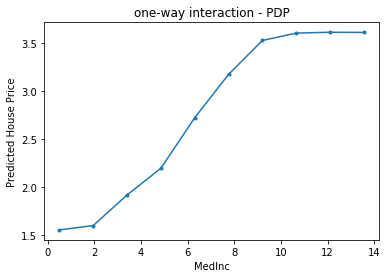

In [22]:
print("DAI Model ...")
simple_plot(result1)

### 5. Build Non-DAI model (h2o-3)

SK-learn Model ...


<module 'matplotlib.pyplot' from '/home/ubuntu/anaconda3/envs/mli_dev/lib/python3.6/site-packages/matplotlib/pyplot.py'>

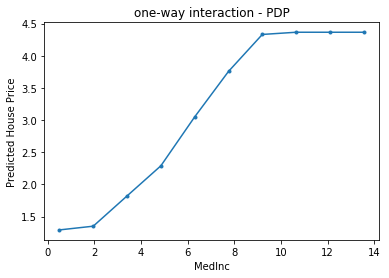

In [23]:
print("SK-learn Model ...")
simple_plot(result2)

In [4]:
## Build a h2o-3 model
import hmli
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: java version "1.8.0_191"; Java(TM) SE Runtime Environment (build 1.8.0_191-b12); Java HotSpot(TM) 64-Bit Server VM (build 25.191-b12, mixed mode)
  Starting server from /home/ubuntu/anaconda3/envs/mli_dev/lib/python3.6/site-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmpv_n3qphw
  JVM stdout: /tmp/tmpv_n3qphw/h2o_ubuntu_started_from_python.out
  JVM stderr: /tmp/tmpv_n3qphw/h2o_ubuntu_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321... successful.


H2O cluster uptime:,01 secs
H2O cluster timezone:,Etc/UTC
H2O data parsing timezone:,UTC
H2O cluster version:,3.22.0.2
H2O cluster version age:,1 month and 12 days
H2O cluster name:,H2O_from_python_ubuntu_6n7ds0
H2O cluster total nodes:,1
H2O cluster free memory:,6.906 Gb
H2O cluster total cores:,8
H2O cluster allowed cores:,8
H2O cluster status:,"accepting new members, healthy"


In [5]:
from hmli.estimators import H2OGradientBoostingEstimator

h2o_frame_train = h2o.H2OFrame(data_df_train)
h2o_frame_test = h2o.H2OFrame(data_df_test)

Parse progress: |█████████████████████████████████████████████████████████| 100%
Parse progress: |█████████████████████████████████████████████████████████| 100%


In [15]:
h2o_frame_train.shape

(16512, 9)

In [6]:
gbm_model = H2OGradientBoostingEstimator(stopping_metric = "rmse",
                                         stopping_rounds = 5, # early stopping
                                         score_tree_interval = 5,
                                         ntrees = 500,
                                         model_id = "gbm.hex")

x = feature_list[:-1]
gbm_model.train(x=x,
                y="target",
                training_frame = h2o_frame_train,
                validation_frame = h2o_frame_test)

gbm Model Build progress: |███████████████████████████████████████████████| 100%


In [20]:
r = gbm_model.predict(h2o_frame_train)

gbm prediction progress: |████████████████████████████████████████████████| 100%


#### 5.1 Generate Explanations

In [40]:
def predict_h2o3(X):
    h2o_frame_train = h2o.H2OFrame(X)
    return list(gbm_model.predict(h2o_frame_train).as_data_frame()['predict'])

In [41]:
start = timer()
pdp2 = PD("Boston Housing PD")
feature_names = ['MedInc']
pdp2.explain(features=feature_names, X=data_df_train, predict_method=predict_h2o3)
end = timer()
print(end - start)

Parse progress: |█████████████████████████████████████████████████████████| 100%
gbm prediction progress: |████████████████████████████████████████████████| 100%
Parse progress: |█████████████████████████████████████████████████████████| 100%
gbm prediction progress: |████████████████████████████████████████████████| 100%
Parse progress: |█████████████████████████████████████████████████████████| 100%
gbm prediction progress: |████████████████████████████████████████████████| 100%
Parse progress: |█████████████████████████████████████████████████████████| 100%
gbm prediction progress: |████████████████████████████████████████████████| 100%
Parse progress: |█████████████████████████████████████████████████████████| 100%
gbm prediction progress: |████████████████████████████████████████████████| 100%
Parse progress: |█████████████████████████████████████████████████████████| 100%
gbm prediction progress: |████████████████████████████████████████████████| 100%
Parse progress: |███████████

In [42]:
result3 = pdp2.explanations()
result3

{'MedInc':       0.49990   1.94992   3.39994   4.84996   6.29998   7.75000   9.20002   \
 mean  1.849422  1.628839  1.933042  2.209001  2.838186  3.194996  3.727800   
 sd    0.767706  0.696918  0.793373  0.855145  0.829973  0.800865  0.742329   
 sem   0.005974  0.005424  0.006174  0.006655  0.006459  0.006232  0.005777   
 
       10.65004  12.10006  13.55008  
 mean  3.895259  3.892909  3.892909  
 sd    0.704119  0.698989  0.698989  
 sem   0.005480  0.005440  0.005440  }

<module 'matplotlib.pyplot' from '/home/ubuntu/anaconda3/envs/mli_dev/lib/python3.6/site-packages/matplotlib/pyplot.py'>

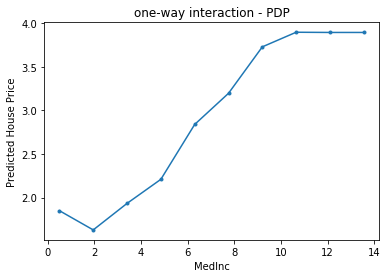

In [45]:
simple_plot(result3)